# Qwen3-1.7B IPO vs Ratio=0.6 결과 비교

이 notebook은 Qwen3-1.7B로 학습한 두 실험을 비교합니다.

- `standard_ipo + length_norm=none`
- `target_ratio + length_norm=none + ratio=0.6`

포함 내용:

1. 저장된 run/final/checkpoint 확인
2. 최종 train/eval metric 요약
3. Train loss curve
4. Actual ratio curve
5. Reward accuracy / margin curve
6. 선택 사항: lm-eval benchmark 실행 및 결과 집계


In [44]:
from pathlib import Path
import os
import json
import re
import shutil
import subprocess

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

try:
    import seaborn as sns
    sns.set_theme(style="whitegrid", context="notebook")
except Exception:
    sns = None

ROOT = Path.cwd()
RUN_ROOT = ROOT / "outputs" / "qwen3_1_7b_ipo_vs_ratio06" / "20260610"
EVAL_ROOT = ROOT / "outputs" / "eval_qwen3_1_7b_ipo_vs_ratio06"
EVAL_ROOT.mkdir(parents=True, exist_ok=True)

os.environ["HF_HOME"] = str(ROOT / ".hf_cache")
os.environ["HF_DATASETS_CACHE"] = str(ROOT / ".hf_cache" / "datasets")
os.environ["PYTHONDONTWRITEBYTECODE"] = "1"

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 200)

def show_path(path):
    path = Path(path)
    try:
        return str(path.relative_to(ROOT))
    except ValueError:
        return str(path)

In [45]:
def parse_run_dir(run_dir):
    name = Path(run_dir).name
    if name.startswith("objective_standard_ipo_norm_none"):
        return {
            "model": "Qwen3-1.7B standard IPO",
            "objective": "standard_ipo",
            "length_norm": "none",
            "target_ratio": np.nan,
        }
    m = re.search(r"objective_target_ratio_norm_none_ratio_([0-9.]+)_", name)
    if m:
        ratio = float(m.group(1))
        return {
            "model": f"Qwen3-1.7B ratio={ratio:.1f}",
            "objective": "target_ratio",
            "length_norm": "none",
            "target_ratio": ratio,
        }
    return {
        "model": name,
        "objective": "unknown",
        "length_norm": "unknown",
        "target_ratio": np.nan,
    }

def latest_state_path(run_dir):
    paths = sorted(
        Path(run_dir).glob("checkpoint-*/trainer_state.json"),
        key=lambda p: int(re.search(r"checkpoint-(\d+)", str(p)).group(1)),
    )
    return paths[-1] if paths else None

rows = []
for run_dir in sorted(RUN_ROOT.iterdir() if RUN_ROOT.exists() else []):
    if not run_dir.is_dir():
        continue
    meta = parse_run_dir(run_dir)
    ckpts = sorted(run_dir.glob("checkpoint-*"), key=lambda p: int(p.name.split("-")[-1]) if p.name.split("-")[-1].isdigit() else -1)
    state_path = latest_state_path(run_dir)
    rows.append({
        **meta,
        "run_dir": run_dir,
        "final_dir": run_dir / "final",
        "latest_state": state_path,
        "num_checkpoints": len(ckpts),
        "has_final": (run_dir / "final" / "model.safetensors").exists(),
    })

runs = pd.DataFrame(rows)
runs[["model", "objective", "length_norm", "target_ratio", "num_checkpoints", "has_final", "run_dir"]]

,model,objective,length_norm,target_ratio,num_checkpoints,has_final,run_dir
0,Qwen3-1.7B standard IPO,standard_ipo,none,NaN,3,True,/home/cvip/qwen3_ipo_exp/outputs/qwen3_1_7b_ip...
1,Qwen3-1.7B ratio=0.6,target_ratio,none,0.6,3,True,/home/cvip/qwen3_ipo_exp/outputs/qwen3_1_7b_ip...


In [46]:
def load_state(path):
    with open(path, "r") as f:
        return json.load(f)

def last_row_with_key(log_history, key):
    for row in reversed(log_history):
        if key in row:
            return row
    return {}

summary_rows = []
for _, run in runs.iterrows():
    state = load_state(run["latest_state"])
    logs = state.get("log_history", [])
    last_train = last_row_with_key(logs, "loss")
    last_eval = last_row_with_key(logs, "eval_loss")
    summary_rows.append({
        "model": run["model"],
        "objective": run["objective"],
        "target_ratio": run["target_ratio"],
        "global_step": state.get("global_step"),
        "epoch": state.get("epoch"),
        "final_train_loss": last_train.get("loss"),
        "final_eval_loss": last_eval.get("eval_loss"),
        "final_train_actual_ratio": last_train.get("target_ratio/actual"),
        "final_eval_actual_ratio": last_eval.get("eval_target_ratio/actual"),
        "final_train_reward_accuracy": last_train.get("rewards/accuracies"),
        "final_eval_reward_accuracy": last_eval.get("eval_rewards/accuracies"),
        "final_train_margin": last_train.get("rewards/margins"),
        "final_eval_margin": last_eval.get("eval_rewards/margins"),
        "final_dir": run["final_dir"],
    })

summary = pd.DataFrame(summary_rows)
summary.to_csv(EVAL_ROOT / "training_summary.csv", index=False)
summary

,model,objective,target_ratio,global_step,epoch,final_train_loss,final_eval_loss,final_train_actual_ratio,final_eval_actual_ratio,final_train_reward_accuracy,final_eval_reward_accuracy,final_train_margin,final_eval_margin,final_dir
0,Qwen3-1.7B standard IPO,standard_ipo,NaN,2709,3.0,631.026758,2065.616699,0.577761,0.522170,0.950,0.678284,0.315524,0.089882,/home/cvip/qwen3_ipo_exp/outputs/qwen3_1_7b_ip...
1,Qwen3-1.7B ratio=0.6,target_ratio,0.6,2709,3.0,0.032390,0.135176,0.569508,0.518543,0.975,0.686327,0.280936,0.074851,/home/cvip/qwen3_ipo_exp/outputs/qwen3_1_7b_ip...


In [47]:
def load_curves(runs_df):
    rows = []
    for _, run in runs_df.iterrows():
        state = load_state(run["latest_state"])
        for row in state.get("log_history", []):
            step = row.get("step")
            if step is None:
                continue
            if "loss" in row:
                rows.append({
                    "model": run["model"],
                    "objective": run["objective"],
                    "split": "train",
                    "step": step,
                    "epoch": row.get("epoch"),
                    "loss": row.get("loss"),
                    "actual_ratio": row.get("target_ratio/actual"),
                    "reward_accuracy": row.get("rewards/accuracies"),
                    "reward_margin": row.get("rewards/margins"),
                    "learning_rate": row.get("learning_rate"),
                    "grad_norm": row.get("grad_norm"),
                })
            if "eval_loss" in row:
                rows.append({
                    "model": run["model"],
                    "objective": run["objective"],
                    "split": "eval",
                    "step": step,
                    "epoch": row.get("epoch"),
                    "loss": row.get("eval_loss"),
                    "actual_ratio": row.get("eval_target_ratio/actual"),
                    "reward_accuracy": row.get("eval_rewards/accuracies"),
                    "reward_margin": row.get("eval_rewards/margins"),
                    "learning_rate": np.nan,
                    "grad_norm": np.nan,
                })
    return pd.DataFrame(rows)

curves = load_curves(runs)
curves.to_csv(EVAL_ROOT / "training_curves.csv", index=False)
curves.tail()

,model,objective,split,step,epoch,loss,actual_ratio,reward_accuracy,reward_margin,learning_rate,grad_norm
591,Qwen3-1.7B ratio=0.6,target_ratio,train,2680,2.968287,0.040982,0.562776,0.975000,0.253598,5.537099e-09,23.752234
592,Qwen3-1.7B ratio=0.6,target_ratio,train,2690,2.979366,0.044579,0.559198,0.950000,0.238875,3.691399e-09,31.673630
593,Qwen3-1.7B ratio=0.6,target_ratio,train,2700,2.990445,0.032390,0.569508,0.975000,0.280936,1.845700e-09,21.179995
594,Qwen3-1.7B ratio=0.6,target_ratio,eval,2700,2.990445,0.136089,0.518192,0.702413,0.073439,NaN,NaN
595,Qwen3-1.7B ratio=0.6,target_ratio,eval,2709,3.000000,0.135176,0.518543,0.686327,0.074851,NaN,NaN


## Train/Eval Reward Accuracy 분리 및 Gap

`reward_accuracy`는 benchmark accuracy가 아니라 preference pair에서 `chosen reward > rejected reward`인 비율입니다.  
Train과 eval의 범위가 크게 달라 한 그래프에 겹치면 차이가 잘 안 보이므로, 아래에서는 train/eval을 분리하고 마지막으로 train-eval gap을 확인합니다.

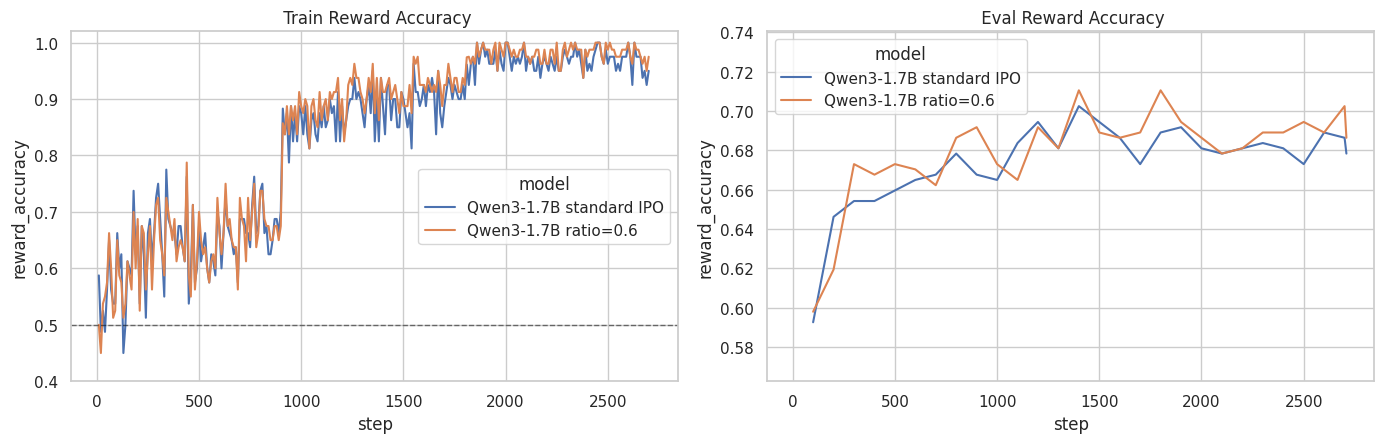

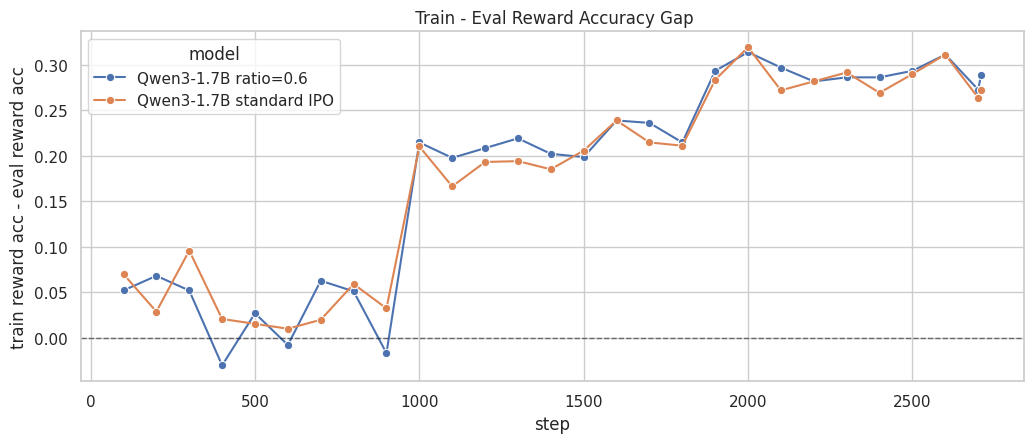

,model,step,reward_accuracy_train,reward_accuracy_eval,train_minus_eval
27,Qwen3-1.7B ratio=0.6,2709,0.975,0.6863,0.2887
55,Qwen3-1.7B standard IPO,2709,0.950,0.6783,0.2717


In [48]:
def plot_train_eval_accuracy_separately(curves, title_prefix=""):
    acc = curves.dropna(subset=["reward_accuracy"]).copy()
    if acc.empty:
        print("No reward_accuracy values found.")
        return

    fig, axes = plt.subplots(1, 2, figsize=(14, 4.6), sharex=True)
    for ax, split, ylim in [
        (axes[0], "train", None),
        (axes[1], "eval", None),
    ]:
        split_df = acc[acc["split"].eq(split)]
        if split_df.empty:
            ax.set_title(f"{split}: no data")
            continue
        if sns:
            sns.lineplot(data=split_df, x="step", y="reward_accuracy", hue="model", ax=ax)
        else:
            for model, g in split_df.groupby("model"):
                ax.plot(g["step"], g["reward_accuracy"], label=model)
            ax.legend()
        ax.set_title(f"{title_prefix} {split.capitalize()} Reward Accuracy")
        ax.set_xlabel("step")
        ax.set_ylabel("reward_accuracy")
        if split == "train":
            low = max(0.0, split_df["reward_accuracy"].min() - 0.05)
            ax.set_ylim(low, 1.02)
        else:
            low = max(0.0, split_df["reward_accuracy"].min() - 0.03)
            high = min(1.0, split_df["reward_accuracy"].max() + 0.03)
            ax.set_ylim(low, high)
        ax.axhline(0.5, color="black", linestyle="--", linewidth=1, alpha=0.5)
    plt.tight_layout()
    plt.show()


def plot_accuracy_gap(curves, title_prefix=""):
    acc = curves.dropna(subset=["reward_accuracy"]).copy()
    if acc.empty:
        print("No reward_accuracy values found.")
        return pd.DataFrame()

    wide = (
        acc.pivot_table(index=["model", "step"], columns="split", values="reward_accuracy", aggfunc="last")
        .reset_index()
    )
    if "train" not in wide.columns or "eval" not in wide.columns:
        print("Need both train and eval reward_accuracy values to compute gap.")
        return wide

    # Eval is logged less often than train. Forward-fill train value at eval steps per model.
    rows = []
    for model, model_acc in acc.groupby("model"):
        train = model_acc[model_acc["split"].eq("train")][["step", "reward_accuracy"]].sort_values("step")
        eval_df = model_acc[model_acc["split"].eq("eval")][["step", "reward_accuracy"]].sort_values("step")
        if train.empty or eval_df.empty:
            continue
        merged = pd.merge_asof(
            eval_df,
            train,
            on="step",
            direction="backward",
            suffixes=("_eval", "_train"),
        )
        merged["model"] = model
        merged["train_minus_eval"] = merged["reward_accuracy_train"] - merged["reward_accuracy_eval"]
        rows.append(merged)

    gap_df = pd.concat(rows, ignore_index=True) if rows else pd.DataFrame()
    if gap_df.empty:
        print("No gap rows computed.")
        return gap_df

    plt.figure(figsize=(10.5, 4.6))
    if sns:
        sns.lineplot(data=gap_df, x="step", y="train_minus_eval", hue="model", marker="o")
    else:
        for model, g in gap_df.groupby("model"):
            plt.plot(g["step"], g["train_minus_eval"], marker="o", label=model)
        plt.legend()
    plt.axhline(0, color="black", linestyle="--", linewidth=1, alpha=0.5)
    plt.title(f"{title_prefix} Train - Eval Reward Accuracy Gap")
    plt.xlabel("step")
    plt.ylabel("train reward acc - eval reward acc")
    plt.tight_layout()
    plt.show()

    final_gap = gap_df.sort_values("step").groupby("model").tail(1)[[
        "model", "step", "reward_accuracy_train", "reward_accuracy_eval", "train_minus_eval"
    ]]
    display(final_gap.sort_values("train_minus_eval", ascending=False).round(4))
    return gap_df

plot_train_eval_accuracy_separately(curves, title_prefix="")
accuracy_gap = plot_accuracy_gap(curves, title_prefix="")

### Actual Ratio Plot 기준

Eval actual ratio는 대부분 0.5 근처에 머물러 방법 비교 시 시각적으로 큰 의미가 적으므로, actual ratio 그래프에서는 train 값만 표시합니다. Eval actual ratio는 summary table에서만 참고합니다.

In [49]:
def plot_train_actual_ratio(curves, title="Train Actual Ratio", ylim=None):
    train_df = curves[(curves["split"].eq("train")) & curves["actual_ratio"].notna()].copy()
    if train_df.empty:
        print("No train actual_ratio values found.")
        return
    plt.figure(figsize=(10.5, 4.8))
    if sns:
        sns.lineplot(data=train_df, x="step", y="actual_ratio", hue="model")
    else:
        for model, g in train_df.groupby("model"):
            plt.plot(g["step"], g["actual_ratio"], label=model)
        plt.legend()
    plt.title(title)
    plt.xlabel("step")
    plt.ylabel("train actual_ratio")
    if ylim:
        plt.ylim(*ylim)
    plt.tight_layout()
    plt.show()

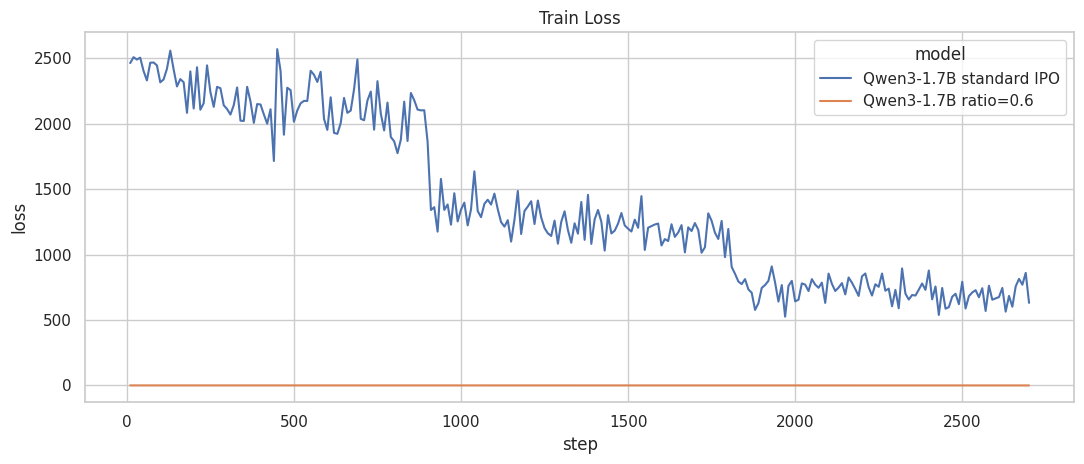

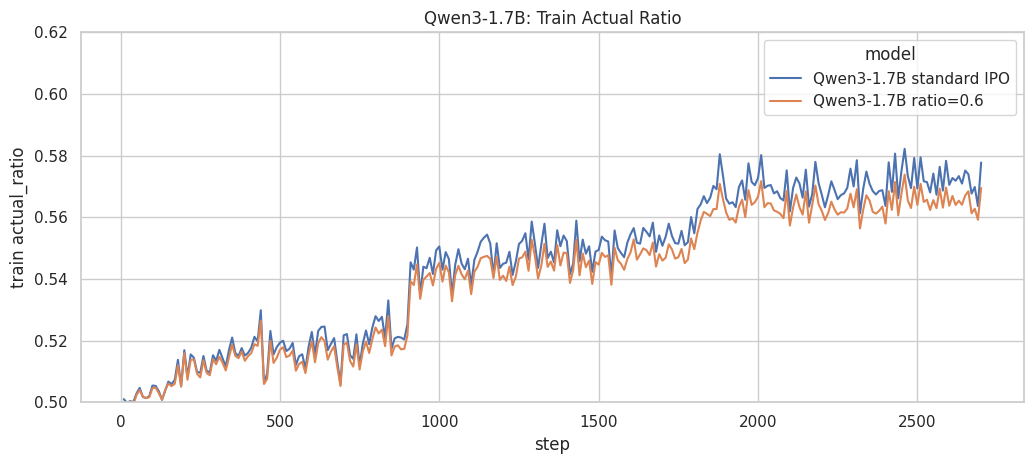

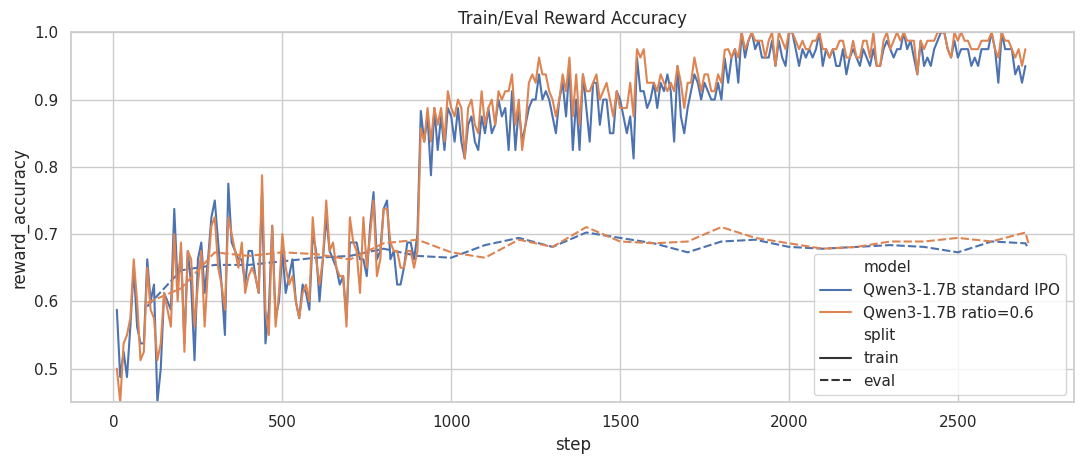

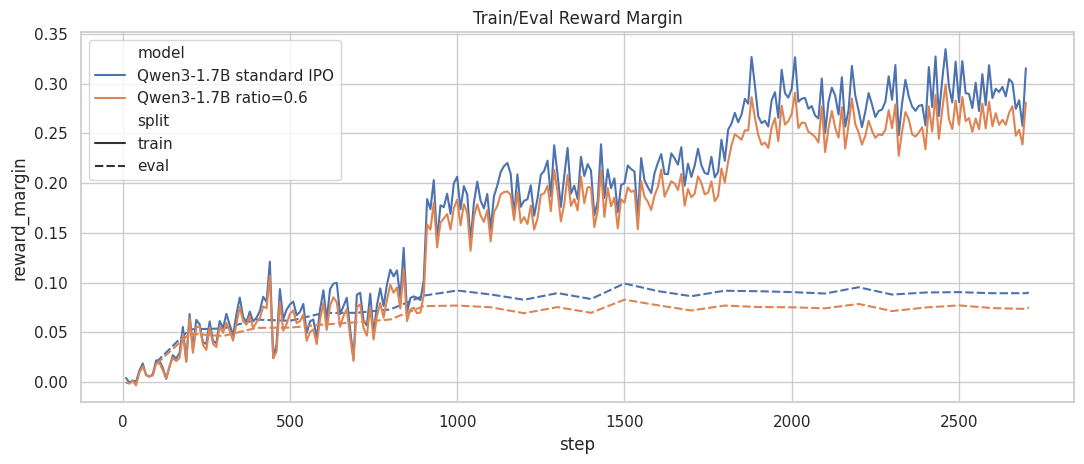

In [50]:
def lineplot_metric(metric, title=None, ylabel=None, ylim=None):
    df = curves.dropna(subset=[metric]).copy()
    plt.figure(figsize=(11, 4.8))
    if sns:
        sns.lineplot(data=df, x="step", y=metric, hue="model", style="split")
    else:
        for (model, split), g in df.groupby(["model", "split"]):
            plt.plot(g["step"], g[metric], label=f"{model} {split}")
        plt.legend()
    plt.title(title or metric)
    plt.xlabel("step")
    plt.ylabel(ylabel or metric)
    if ylim:
        plt.ylim(*ylim)
    plt.tight_layout()
    plt.show()


def lineplot_train_metric(metric, title=None, ylabel=None, ylim=None):
    df = curves[(curves["split"].eq("train"))].dropna(subset=[metric]).copy()
    plt.figure(figsize=(11, 4.8))
    if sns:
        sns.lineplot(data=df, x="step", y=metric, hue="model")
    else:
        for model, g in df.groupby("model"):
            plt.plot(g["step"], g[metric], label=model)
        plt.legend()
    plt.title(title or metric)
    plt.xlabel("step")
    plt.ylabel(ylabel or metric)
    if ylim:
        plt.ylim(*ylim)
    plt.tight_layout()
    plt.show()

lineplot_train_metric("loss", "Train Loss")
plot_train_actual_ratio(curves, "Qwen3-1.7B: Train Actual Ratio", ylim=(0.50, 0.62))
lineplot_metric("reward_accuracy", "Train/Eval Reward Accuracy", ylim=(0.45, 1.0))
lineplot_metric("reward_margin", "Train/Eval Reward Margin")


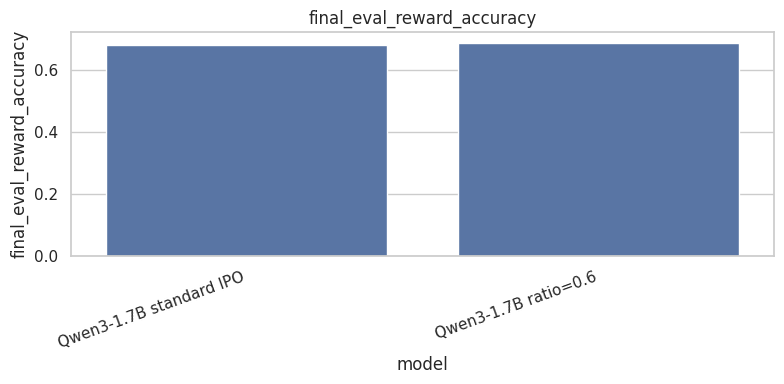

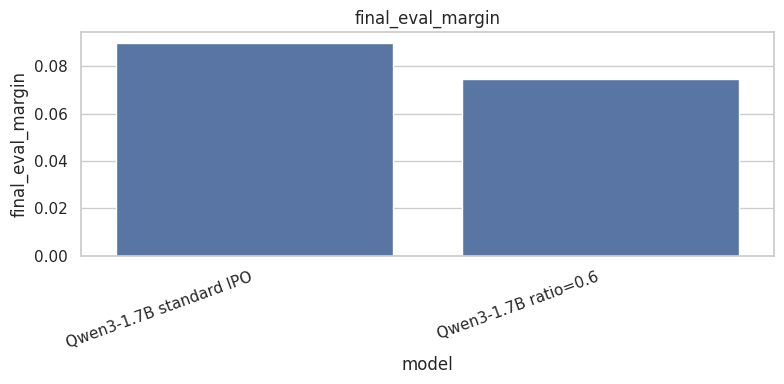

,model,final_eval_loss,final_eval_actual_ratio,final_eval_reward_accuracy,final_eval_margin
0,Qwen3-1.7B standard IPO,2065.616699,0.522170,0.678284,0.089882
1,Qwen3-1.7B ratio=0.6,0.135176,0.518543,0.686327,0.074851


In [51]:
# 최종 eval 지표만 보기 좋은 bar chart로 비교합니다.
final_eval = summary[[
    "model",
    "final_eval_loss",
    "final_eval_actual_ratio",
    "final_eval_reward_accuracy",
    "final_eval_margin",
]].copy()

for metric in ["final_eval_reward_accuracy", "final_eval_margin"]:
    plt.figure(figsize=(8, 4))
    if sns:
        sns.barplot(data=final_eval, x="model", y=metric)
    else:
        plt.bar(final_eval["model"], final_eval[metric])
    plt.xticks(rotation=20, ha="right")
    plt.title(metric)
    plt.tight_layout()
    plt.show()

final_eval

## Benchmark Comparison: ARC / HellaSwag / TruthfulQA / Winogrande

아래 셀은 Qwen3-1.7B `standard IPO`와 `ratio=0.6 IPO`를 lm-eval benchmark로 비교합니다.

평가 태스크:

- `arc_challenge`
- `arc_easy`
- `hellaswag`
- `truthfulqa_mc2`
- `winogrande`

처음 실행하면 시간이 오래 걸릴 수 있습니다. 기본값은 `RUN_LM_EVAL = False`이며, 실제 평가를 돌리려면 `True`로 바꾼 뒤 실행하세요. 이미 결과가 있으면 자동으로 재사용합니다.

In [52]:
RUN_LM_EVAL = False
BENCHMARK_TASKS = [
    "arc_challenge",
    "arc_easy",
    "hellaswag",
    "truthfulqa_mc2",
    "winogrande",
]
TASKS = ",".join(BENCHMARK_TASKS)
LM_EVAL_BIN = shutil.which("lm_eval") or str(ROOT / ".venv" / "bin" / "lm_eval")

def safe_name(name):
    return (
        name.replace("Qwen3-1.7B ", "")
        .replace(" ", "_")
        .replace("=", "eq")
        .replace(".", "p")
    )

def benchmark_output_dir(model_name):
    return EVAL_ROOT / safe_name(model_name)

def benchmark_result_file(model_name):
    out_dir = benchmark_output_dir(model_name)
    direct = out_dir / "results.json"
    if direct.exists():
        return direct
    timestamped = sorted(out_dir.glob("**/results_*.json"))
    return timestamped[-1] if timestamped else direct

def lm_eval_command(row):
    out_dir = benchmark_output_dir(row["model"])
    return [
        LM_EVAL_BIN,
        "run",
        "--model", "hf",
        "--model_args", f"pretrained={row['final_dir']},trust_remote_code=True,dtype=bfloat16",
        "--tasks", TASKS,
        "--device", "cuda:0",
        "--batch_size", "auto",
        "--output_path", str(out_dir),
    ]

commands = []
for _, row in summary.iterrows():
    commands.append({
        "model": row["model"],
        "result_file": benchmark_result_file(row["model"]),
        "exists": benchmark_result_file(row["model"]).exists(),
        "command": " ".join(map(str, lm_eval_command(row))),
    })

pd.DataFrame(commands)

,model,result_file,exists,command
0,Qwen3-1.7B standard IPO,/home/cvip/qwen3_ipo_exp/outputs/eval_qwen3_1_...,True,/home/cvip/qwen3_ipo_exp/.venv/bin/lm_eval run...
1,Qwen3-1.7B ratio=0.6,/home/cvip/qwen3_ipo_exp/outputs/eval_qwen3_1_...,True,/home/cvip/qwen3_ipo_exp/.venv/bin/lm_eval run...


In [53]:
def run_lm_eval_for_model(row):
    out_dir = benchmark_output_dir(row["model"])
    result_file = benchmark_result_file(row["model"])
    if result_file.exists():
        print(f"Reusing {show_path(result_file)}")
        return result_file

    out_dir.mkdir(parents=True, exist_ok=True)
    cmd = lm_eval_command(row)
    print("Running:", " ".join(map(str, cmd)))
    subprocess.run(cmd, check=True)
    if not result_file.exists():
        raise FileNotFoundError(f"Expected lm-eval results at {result_file}")
    return result_file

if RUN_LM_EVAL:
    result_paths = []
    for _, row in summary.iterrows():
        result_paths.append(run_lm_eval_for_model(row))
    print("Finished benchmark evaluation")
    result_paths
else:
    print("RUN_LM_EVAL is False. Set it to True to run ARC/HellaSwag/TruthfulQA/Winogrande evaluation.")

RUN_LM_EVAL is False. Set it to True to run ARC/HellaSwag/TruthfulQA/Winogrande evaluation.


In [54]:
def extract_lm_eval_results(path):
    data = json.loads(Path(path).read_text())
    rows = []
    task_name = {
        "arc_challenge": "ARC-Challenge",
        "arc_easy": "ARC-Easy",
        "hellaswag": "HellaSwag",
        "truthfulqa_mc2": "TruthfulQA MC2",
        "winogrande": "Winogrande",
    }
    for task, metrics in data.get("results", {}).items():
        if "acc_norm,none" in metrics:
            metric_key = "acc_norm,none"
            metric = "acc_norm"
        elif "acc,none" in metrics:
            metric_key = "acc,none"
            metric = "acc"
        else:
            numeric_keys = [k for k, v in metrics.items() if isinstance(v, (int, float))]
            if not numeric_keys:
                continue
            metric_key = numeric_keys[0]
            metric = metric_key.replace(",none", "")
        rows.append({
            "Task": task_name.get(task, task),
            "Metric": metric,
            "Score": metrics.get(metric_key),
        })
    return pd.DataFrame(rows)

bench_rows = []
missing = []
for _, row in summary.iterrows():
    path = benchmark_result_file(row["model"])
    if not path.exists():
        missing.append(row["model"])
        continue
    df = extract_lm_eval_results(path)
    df["model"] = row["model"]
    bench_rows.append(df)

if bench_rows:
    benchmark = pd.concat(bench_rows, ignore_index=True)
    benchmark_comparison = (
        benchmark
        .pivot_table(index=["Task", "Metric"], columns="model", values="Score")
        .reset_index()
    )
    model_cols = [c for c in benchmark_comparison.columns if c not in ["Task", "Metric"]]
    if len(model_cols) == 2:
        baseline = "Qwen3-1.7B standard IPO" if "Qwen3-1.7B standard IPO" in model_cols else model_cols[0]
        other = [c for c in model_cols if c != baseline][0]
        benchmark_comparison[f"{other} - {baseline}"] = benchmark_comparison[other] - benchmark_comparison[baseline]

    benchmark_comparison.to_csv(EVAL_ROOT / "benchmark_comparison.csv", index=False)
    display(benchmark_comparison)

    ranking = benchmark_comparison[model_cols].mean().rename("mean_score").sort_values(ascending=False)
    ranking.to_csv(EVAL_ROOT / "benchmark_ranking.csv")
    display(ranking)
else:
    benchmark_comparison = pd.DataFrame()
    print("No benchmark result files found yet.")

if missing:
    print("Missing benchmark results for:", missing)
    print("Set RUN_LM_EVAL = True and run the evaluation cell above.")

model,Task,Metric,Qwen3-1.7B ratio=0.6,Qwen3-1.7B standard IPO,Qwen3-1.7B ratio=0.6 - Qwen3-1.7B standard IPO
0,ARC-Challenge,acc_norm,0.430034,0.430887,-0.000853
1,ARC-Easy,acc_norm,0.702020,0.698232,0.003788
2,HellaSwag,acc_norm,0.608146,0.609142,-0.000996
3,TruthfulQA MC2,acc,0.461442,0.460990,0.000452
4,Winogrande,acc,0.612470,0.606946,0.005525


model
Qwen3-1.7B ratio=0.6       0.562822
Qwen3-1.7B standard IPO    0.561239
Name: mean_score, dtype: float64

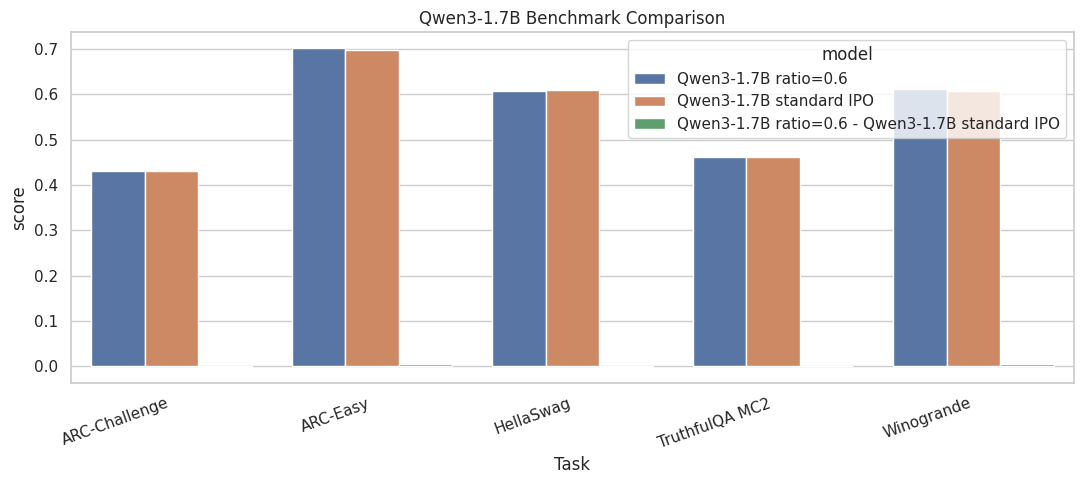

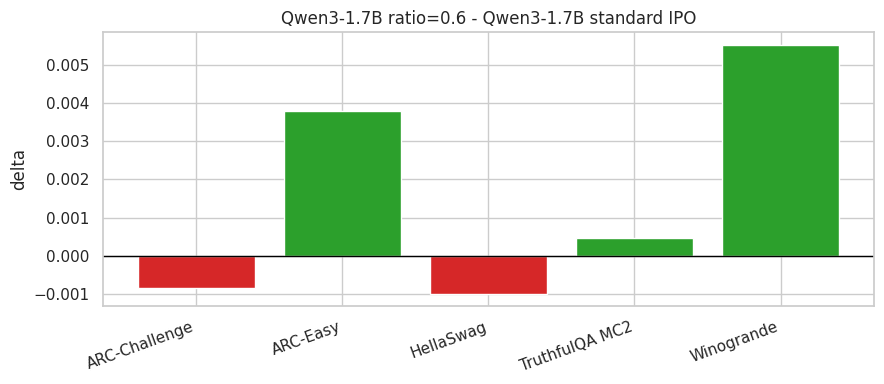

In [55]:
if not benchmark_comparison.empty:
    model_cols = [c for c in benchmark_comparison.columns if c.startswith("Qwen3-1.7B")]
    if len(model_cols) >= 2:
        plot_df = benchmark_comparison.melt(
            id_vars=["Task", "Metric"],
            value_vars=model_cols,
            var_name="model",
            value_name="score",
        )
        plt.figure(figsize=(11, 5))
        if sns:
            sns.barplot(data=plot_df, x="Task", y="score", hue="model")
        else:
            for model, g in plot_df.groupby("model"):
                plt.plot(g["Task"], g["score"], marker="o", label=model)
            plt.legend()
        plt.xticks(rotation=20, ha="right")
        plt.title("Qwen3-1.7B Benchmark Comparison")
        plt.ylabel("score")
        plt.tight_layout()
        plt.show()

        delta_cols = [c for c in benchmark_comparison.columns if " - " in c]
        if delta_cols:
            delta_col = delta_cols[0]
            plt.figure(figsize=(9, 4))
            colors = ["#2ca02c" if v >= 0 else "#d62728" for v in benchmark_comparison[delta_col]]
            plt.bar(benchmark_comparison["Task"], benchmark_comparison[delta_col], color=colors)
            plt.axhline(0, color="black", linewidth=1)
            plt.xticks(rotation=20, ha="right")
            plt.title(delta_col)
            plt.ylabel("delta")
            plt.tight_layout()
            plt.show()
else:
    print("Run benchmark extraction after lm-eval results exist.")

## 해석 기준

- `ratio=0.6`이 `standard IPO`보다 평균 score가 높으면, 1.7B에서도 fixed ratio가 downstream benchmark 보존에 도움이 된 것으로 볼 수 있습니다.
- `actual ratio` 차이는 작더라도 benchmark에서 이기면 ratio objective가 일반 성능 보존에 유리했을 가능성이 있습니다.
- 반대로 benchmark가 비슷하거나 낮으면, 1.7B에서는 `ratio=0.6` 고정의 실질적 이득이 제한적이라고 해석하는 것이 적절합니다.